# ISO 20414:2020 — Test 17: Route Choice Based on Geometric Layout

A two-floor structure (ISO 20414:2020 Figure 13). Start area and target area are connected by two flights of stairs and a corridor on the ground floor and by a longer corridor on the upper floor. Occupant either chooses the shortest path using the lower floor in the journey or they use the longer path on the upper floor. The path should match the underlying route choice implemented in the evacuation model. 

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 17 June 2026, 12:47 CEST


In [2]:
from pathlib import Path
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
import matplotlib.patches as patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.geometry import Point, Polygon
from shapely import from_wkt
from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

In [5]:
import json, tempfile
from scenario_builders.iso17_route_choice import (
    build_raw_scenario, build_geometry_wkt, route_length_reference,
    measure_route_choice, START_POS, TARGET_POS,
)

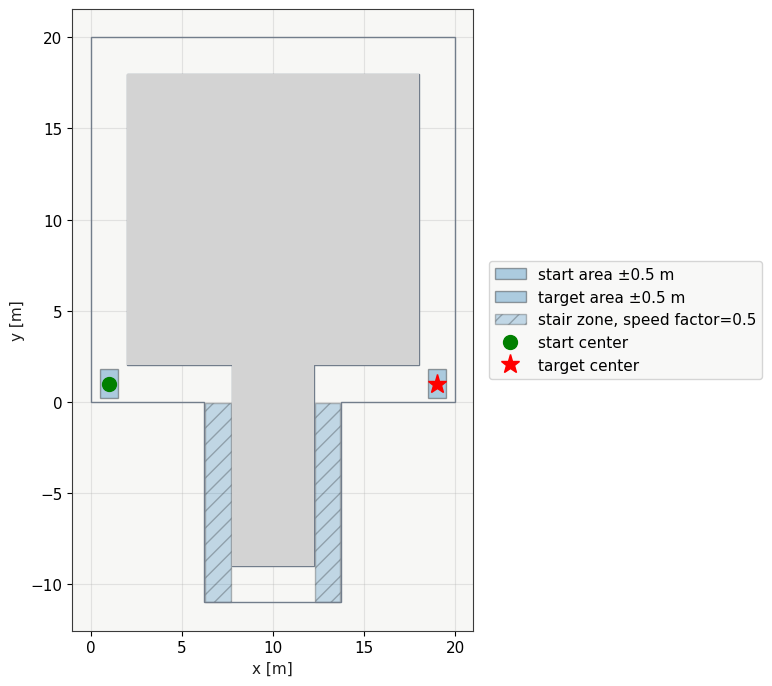

In [ ]:
walkable_area = pedpy.WalkableArea(from_wkt(build_geometry_wkt()))
raw = build_raw_scenario()
fig, ax = plt.subplots(figsize=(7, 7))
pedpy.plot_walkable_area(walkable_area=walkable_area, axes=ax)
def add_polygon(ax, coordinates, alpha=0.35, hatch=None, zorder=4):
    poly = patches.Polygon(
        coordinates,
        closed=True,
        fill=True,
        alpha=alpha,
        hatch=hatch,
        edgecolor="black",
        linewidth=1.0,
        zorder=zorder,
    )
    ax.add_patch(poly)
start_area = raw["distributions"]["jps-distributions_0"]["coordinates"]
target_area = raw["exits"]["jps-exits_0"]["coordinates"]
add_polygon(ax, start_area, alpha=0.35, zorder=6)
add_polygon(ax, target_area, alpha=0.35, zorder=6)
for zone in raw["zones"].values():
    add_polygon(
        ax,
        zone["coordinates"],
        alpha=0.25,
        hatch="//",
        zorder=5,
    )
ax.plot(*START_POS, "go", markersize=10, zorder=8)
ax.plot(*TARGET_POS, "r*", markersize=14, zorder=8)
legend_handles = [
    Patch(facecolor="C0", edgecolor="black", alpha=0.35, label="start area ±0.5 m"),
    Patch(facecolor="C0", edgecolor="black", alpha=0.35, label="target area ±0.5 m"),
    Patch(facecolor="C0", edgecolor="black", alpha=0.25, hatch="//", label="stair zone, speed factor=0.5"),
    plt.Line2D([], [], color="green", marker="o", linestyle="None", markersize=10, label="start center"),
    plt.Line2D([], [], color="red", marker="*", linestyle="None", markersize=14, label="target center"),
]
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()

## Build and Run 

In [7]:
raw = build_raw_scenario()
with tempfile.TemporaryDirectory() as d:
    p = Path(d)
    (p / 'config.json').write_text(json.dumps(raw, indent=2), encoding='utf-8')
    (p / 'geometry.wkt').write_text(build_geometry_wkt(), encoding='utf-8')
    scenario = load_scenario(str(p))
    result = run_scenario(scenario, seed=42)
    traj = result.trajectory_dataframe()
    frame_rate = result.frame_rate
    choice = measure_route_choice(traj, frame_rate)
    result.cleanup()
df = pd.DataFrame.from_dict(choice, orient='index', columns=['value'])
df

DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 10, 'radius': 0.15, 'v0': 1.2, 'distribution_mode': 'by_number', 'radius_distribution': 'constant', 'v0_distribution': 'constant', 'use_flow_spawning': False}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 10, 'radius': 0.15, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
DEBUG: Processing distribution with dist_key = 'jps-distributions_0'
DEBUG: Available journeys_per_distribution keys = ['jps-distributions_0']
DEBUG: dist_key = 'jps-distributions_0', found 1 distribution_journeys
Distribution jps-distributions_0 has 1 journey variants
Variant v2_jps-journeys_

,value
n_shortcut,10.0
n_long_way,0.0
frac_shortcut,1.0


## Plot Trajectories

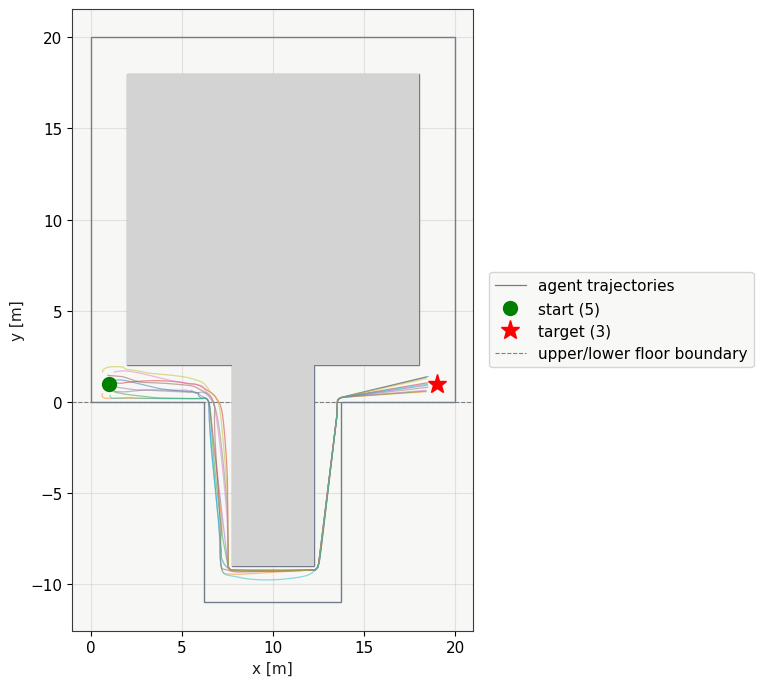

In [ ]:

walkable_area = pedpy.WalkableArea(result.walkable_polygon)
fig, ax = plt.subplots(figsize=(7, 7))
pedpy.plot_walkable_area(walkable_area=walkable_area, axes=ax)
for agent_id, sub in traj.groupby("id"):
    sub = sub.sort_values("frame")
    ax.plot(sub.x, sub.y, alpha=0.5, linewidth=0.9, label="_nolegend_")
ax.plot(*START_POS, "go", markersize=10, zorder=5)
ax.plot(*TARGET_POS, "r*", markersize=14, zorder=5)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8, zorder=2)
legend_handles = [
    Line2D(
        [],
        [],
        color="black",
        linewidth=0.9,
        alpha=0.5,
        label="agent trajectories",
    ),
    Line2D(
        [],
        [],
        color="green",
        marker="o",
        linestyle="None",
        markersize=10,
        label="start (5)",
    ),
    Line2D(
        [],
        [],
        color="red",
        marker="*",
        linestyle="None",
        markersize=14,
        label="target (3)",
    ),
    Line2D(
        [],
        [],
        color="gray",
        linestyle="--",
        linewidth=0.8,
        label="upper/lower floor boundary",
    ),
]
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()

##  Acceptance

Test 17 passes if agents prefer the geometrically shorter route. Given the reference lengths below, the stair shortcut is shorter than going the long way around the ring, so the large majority of agents should be classified as having taken it.

In [9]:
ref = route_length_reference()
print(f"reference lengths: long way = {ref['long_way_m']:.1f} m, "
      f"shortcut = {ref['shortcut_m']:.1f} m")
print(f"agents via shortcut: {choice['n_shortcut']}, "
      f"via long way: {choice['n_long_way']}, "
      f"fraction via shortcut: {choice['frac_shortcut']:.2%}")

assert ref['shortcut_m'] < ref['long_way_m'], (
    "Geometry error: the shortcut is not actually shorter than the long way; "
    "Test 17 is meaningless with these dimensions."
)
assert choice['frac_shortcut'] > 0.5, choice

reference lengths: long way = 54.0 m, shortcut = 30.0 m
agents via shortcut: 10, via long way: 0, fraction via shortcut: 100.00%
